<a href="https://colab.research.google.com/github/Amoako419/10_ML_projects/blob/main/GEN_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Google Colab Notebook for Gemini API (because free?)

Follow link to set-up API key
https://ai.google.dev/gemini-api/docs/api-key#windows

In [8]:
import numpy as np

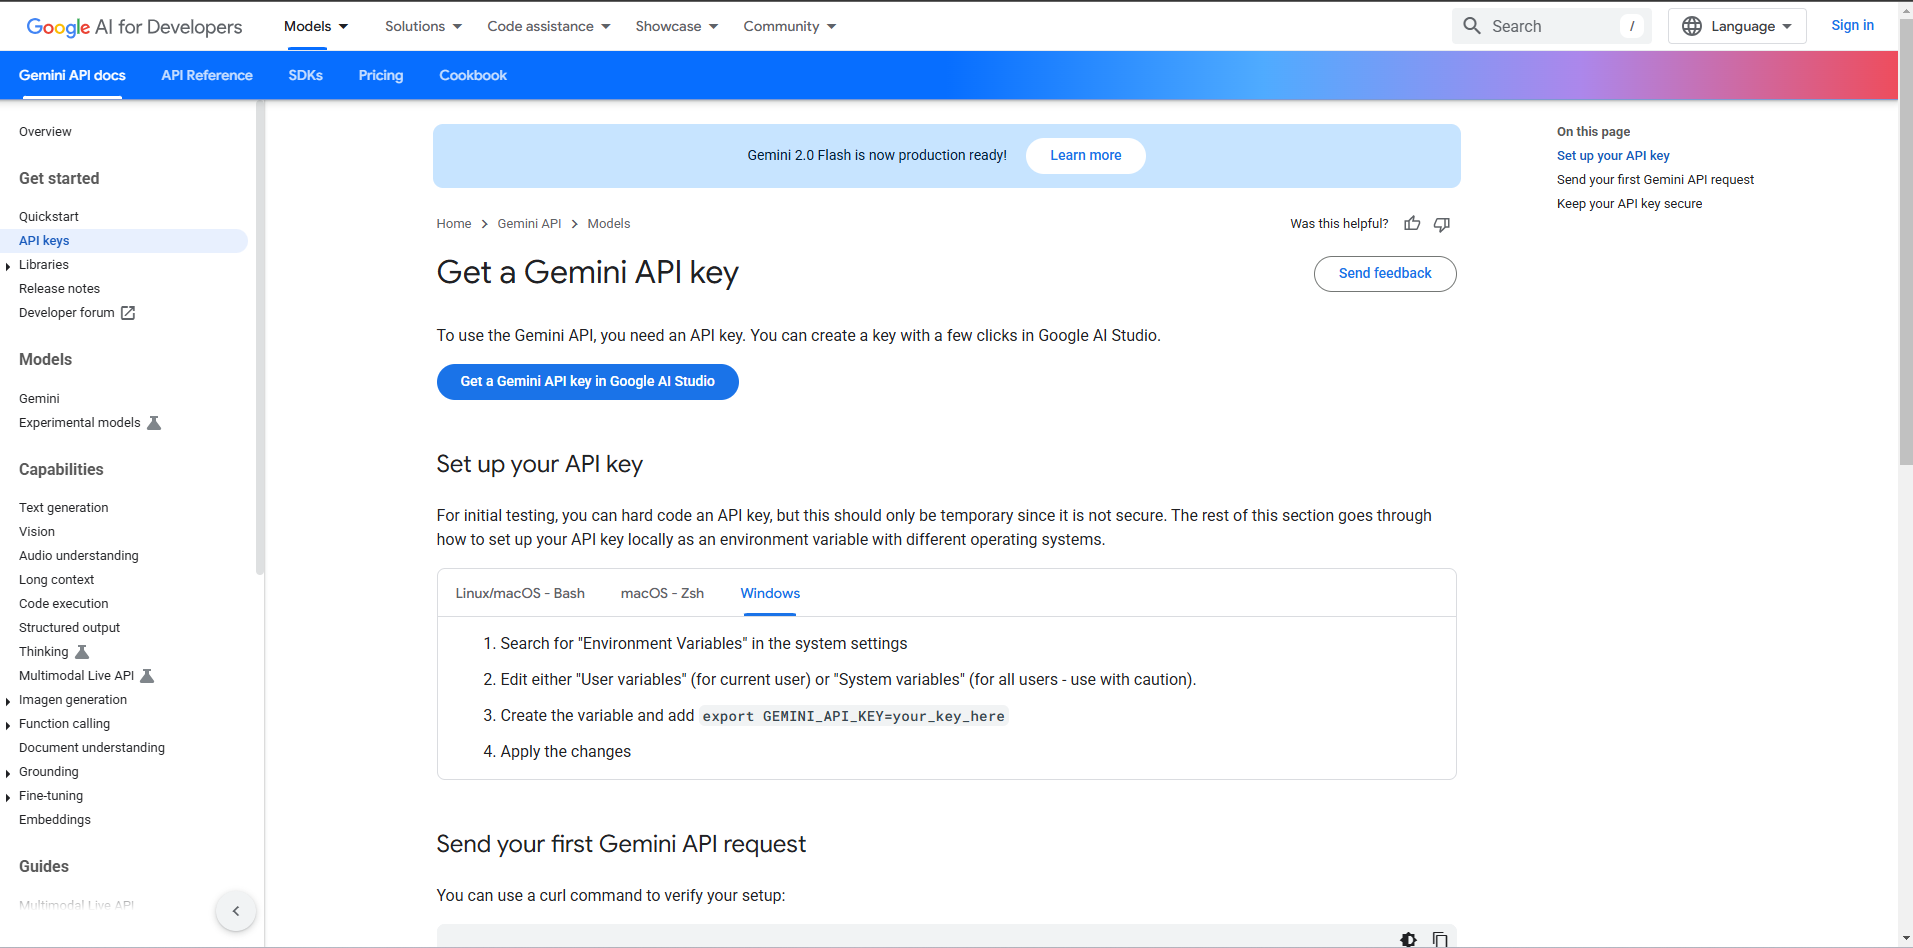

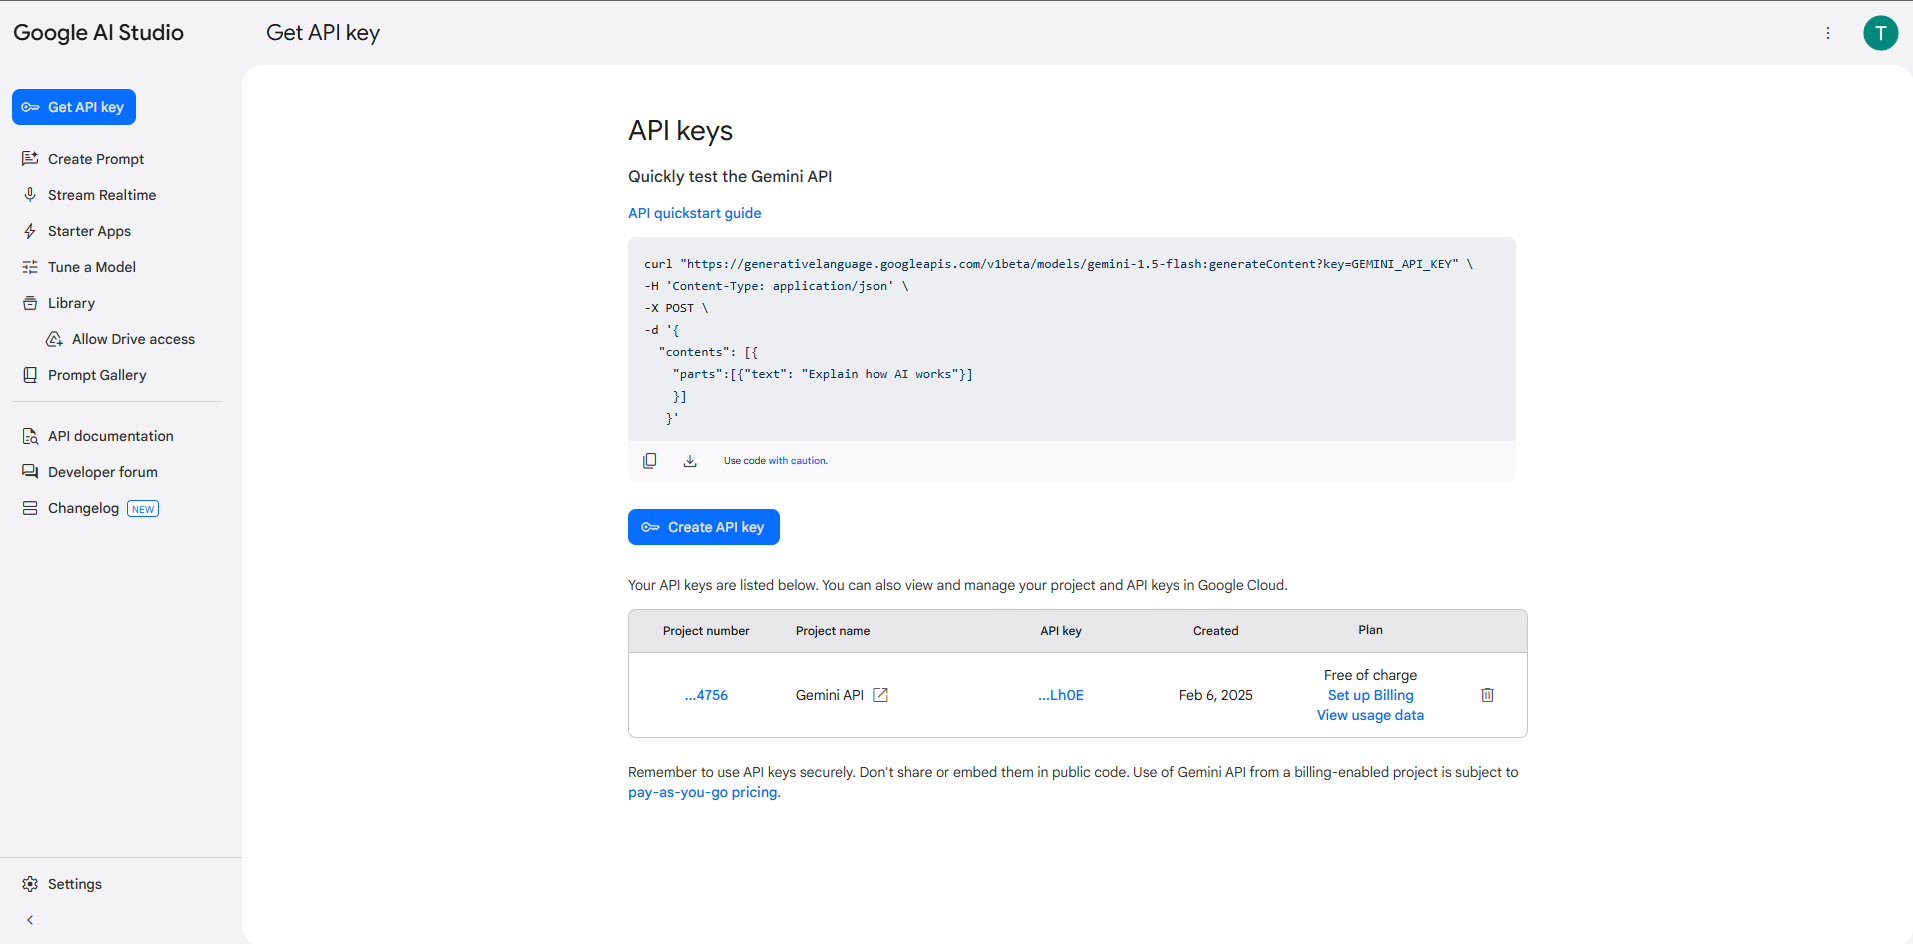

#### Step 2: Set up API Key

In [15]:
# === Code Cell ===
from google.colab import userdata

In [17]:
# === Code Cell ===
!pip install -q -U google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.8 MB/s eta 0:00:00


In [18]:
# === Code Cell ===
from google import genai

In [19]:
# === Code Cell ===
api_key = userdata.get('GOOGLE_API_KEY')
client = genai.Client(api_key=api_key)

#### Step 3: Basic API Call

In [20]:
# === Code Cell ===
from IPython.core.display import display, Markdown

In [21]:
# === Code Cell ===
#function to format model output
def generate_text(prompt):
    response = client.models.generate_content(
        model="gemini-2.0-flash", contents=prompt
    )
    return response.text

In [22]:
# === Code Cell ===
def display_response(response_text):
    """
    Displays the response as markdown in Colab.
    Handles empty responses gracefully.
    """
    if response_text:
        try:
            display(Markdown(response_text))  # --- Render Markdown
        except Exception as e:
            print("Error displaying markdown:", str(e))
            print(response_text)  # --- Fallback to plain text
    else:
        print("No response received.")


In [26]:
# === Code Cell ===
# --- Test the API
prompt = "How many r's are in strawberry"
response = generate_text(prompt)
display_response(response)

There are **two** "r"s in the word "strawberry".


In [29]:
# === Code Cell ===
def list_gemini_models():
    models = client.models.list()
    for model in models:
        print(model.name)

In [30]:
# === Code Cell ===
# --- Run the function
list_gemini_models()

#### Step 4: Generate text from text-and-image input

The Gemini API supports multimodal inputs that combine text and media files.

In [38]:
# === Code Cell ===
# --- get responses from uploaded image
from PIL import Image

image = Image.open("/content/calendar.jpg")
response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=[image, "Tell me about this instrument"])

In [39]:
# === Code Cell ===
display_response(response.text)

The image shows a calendar page. 

*   **Day of the week:** Monday
*   **Date:** 6

In [40]:
# === Code Cell ===
# --- Load multiple images
image1 = Image.open("/content/war.jpg")
image2 = Image.open("/content/pizza.jpg")

# --- Send both images along with a prompt
response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=[image1, image2, "Tell me about these images"]
)

In [41]:
# === Code Cell ===
# --- Display response
display_response(response.text)

The first image is a stylized illustration of a historical battle scene. It features silhouetted figures on horseback and on foot, engaged in combat against a backdrop of mountains and an orange sky. It gives the impression of a dramatic and intense clash, possibly depicting a conflict from the colonial era or similar historical period.

The second image is a close-up shot of a slice of pepperoni pizza on a white background. The focus is on the details of the pizza, including the melted cheese, pepperoni slices, sauce, and crust. The image is well-lit and appears appetizing.


In [42]:
# === Code Cell ===
# --- AI Pickup line generator
image1 = Image.open("/content/pizza.jpg")
image2 = Image.open("/content/moon.jpg")
image3 = Image.open("/content/heart.jpg")
image4 = Image.open("/content/mountain.jpg")

# --- Send images along with a prompt
response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=[image1, image2, image3, image4, "Generate a pickup line using ALL these images"]
)

# --- Display response
display_response(response.text)

"Are you like this snowy mountain? Because you take my breath away." (Mountain Image)

"And like this heart, (Heart Image) you make me feel warm inside."

"Baby, you shine brighter than the moon tonight" (Moon Image)

"And just like this pizza, (Pizza Image) I want a slice of you."


In [ ]:
# === Code Cell ===


In [47]:
# === Code Cell ===
#AI Story Generator (Objects into a Tale)
image1 = Image.open("/content/castle.jpg")
image2 = Image.open("/content/lion.jpg")
image3 = Image.open("/content/bow and arrow.jpg")
image4 = Image.open("/content/moon.jpg")

# --- Send images along with a prompt
response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=[image1, image2, image3, image4, "Create a short lyrics using ALL these images relating to valentine"]
)

# --- Display response
display_response(response.text)

(Image 1: Castle)
Our love's a fortress, strong and tall,
Standing firm, protecting all.

(Image 2: Lion)
My heart's a lion, fierce and bold,
Only for you, its story told.

(Image 3: Archer)
Like an archer, my aim is true,
My heart is set, only on you.

(Image 4: Moon)
You're my bright moon, in darkest night,
Guiding my path, with gentle light.

(Chorus)
This Valentine's, my love's declared,
A castle, lion, archer, moon paired. 
Forever yours, my heart's decree,
My Valentine, eternally!


In [ ]:
# === Code Cell ===


In [51]:
# === Code Cell ===
#AI Meme Caption Generator
image1 = Image.open("/content/cat.jpg")
image2 = Image.open("/content/coffee.jpg")
image3 = Image.open("/content/calendar.jpg")

# --- Send images along with a prompt
response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=[image1, image2, image3, image4, "Create a meme caption using ALL these images"]
)

# --- Display response
display_response(response.text)

Okay, here's a meme caption idea using the images you provided, playing on the perceived grumpiness of Mondays and using the cat's expression:

**Image 1:** (Cat with funny teeth drawing over its face)
**Image 2:** (Calendar showing "Monday 6")
**Image 3:** (Full moon at night)

**Caption:**  "Me pretending to be happy about the Moon-day when I find out what day it is:"


#### Step 5: System Prompts

In [54]:
# === Code Cell ===
from google.genai import types

def generate_with_system_prompt(system_prompt, user_prompt):
    response = client.models.generate_content(
        model="gemini-2.0-flash",
        config=types.GenerateContentConfig(
          system_instruction=system_prompt),
        contents=user_prompt
    )
    return response.text

In [ ]:
# === Code Cell ===
# --- Example Usage
system_prompt = (
    "You are a highly experienced business consultant specializing in startup growth and strategy. "
    "Your responses should include structured frameworks, real-world examples, and action steps where applicable. "
    "Use a professional tone and keep answers concise yet informative."
)

In [ ]:
# === Code Cell ===
user_prompt = "What are the key steps in writing a business plan?"
response = generate_with_system_prompt(system_prompt, user_prompt)
display_response(response)

#### Step 6: Mini Project - AI Chatbot with Expert Personality

In [ ]:
# === Code Cell ===
def chatbot(system_prompt):
    print("AI Chatbot Initialized. Type 'exit' to quit.")
    while True:
        user_input = input("You: ")
        if user_input.lower() == "exit":
            break
        response = generate_with_system_prompt(system_prompt, user_input)
        display_response(response)

In [ ]:
# === Code Cell ===
# --- Run chatbot with a domain expert personality
system_prompt = (
    "You are a domain expert in artificial intelligence and emerging technologies. "
    "Provide detailed, well-structured explanations backed by research and best practices. "
    "Your responses should be clear, engaging, and educational."
)
chatbot(system_prompt)

#### Step 7: Mini Project - AI Content Generator (Emails, Blogs, Social Media)

In [52]:
# === Code Cell ===
def content_generator(topic, style):
    system_prompt = (
        f"You are a professional content strategist with expertise in {style} writing. "
        "Ensure that your responses include engaging introductions, clear structure, and a compelling conclusion."
    )
    user_prompt = f"Write a short blog post about {topic}."
    return generate_with_system_prompt(system_prompt, user_prompt)

In [ ]:
# === Code Cell ===
# --- Example Usage
display_response(content_generator("The impact of AI in business", "professional"))

In [55]:
# === Code Cell ===
# --- Example Usage
display_response(content_generator("The impact of AI in business", "flirty"))

Alright, darling, let's talk AI. Not the sci-fi kind that's going to steal your job (probably), but the savvy, behind-the-scenes kind that's reshaping the very landscape of business. Buckle up, because this is a thrilling ride into the future!

**Title: AI: Your Business's Secret Weapon (Or, Why You Need to Stop Ignoring the Robots)**

**Introduction: Ready to Meet Your New Best Friend?**

Let's be honest, the term "Artificial Intelligence" can sound a little intimidating. Images of sentient robots and dystopian futures might dance in your head. But forget all that for a second. In the business world, AI isn't about replacing humans; it's about *augmenting* them. It's about giving your business a super-powered brain, capable of processing information and making decisions faster and more accurately than ever before. Think of it as your business's personal genius – just waiting to be unleashed.

**The Deliciously Practical Impact: How AI is Turning Heads**

So, how exactly is this "genius" manifesting itself in the business world? Here are just a few ways AI is making waves (and profits!):

*   **Customer Service That Sizzles:** Chatbots powered by AI are providing instant, personalized support 24/7. No more frustrating hold times or generic responses. AI chatbots are ready to flirt your customers into becoming loyal fans!
*   **Smarter Than Sherlock: Data Analysis That's Astounding:** AI can sift through mountains of data to identify patterns and trends that humans would miss. This means better decision-making, targeted marketing, and a deeper understanding of your customers.
*   **Operation Efficiency, Activated:** From automating repetitive tasks to optimizing supply chains, AI is streamlining operations and boosting productivity.
*   **Personalized Marketing That Hits the Spot:** AI is helping businesses create hyper-personalized marketing campaigns that resonate with individual customers. Think product recommendations that feel like they were chosen just for them.

**Future is Now: Don't Be Left in the Dust**

AI isn't some far-off dream; it's happening right now. Businesses that embrace AI are gaining a competitive edge, and those that don't risk being left behind. Start small. Explore how AI can solve a specific problem in your business. Experiment with different tools and technologies.

**Conclusion: The Future is Intelligent, and It's Waiting for You**

The impact of AI in business is undeniable. It's not just a trend; it's a fundamental shift in the way we work. By embracing AI, you can unlock new levels of efficiency, innovation, and customer engagement. So, are you ready to give your business the AI advantage? Trust me, darling, you won't regret it. This is one relationship that's built to last!

Now, go out there and conquer the future! 😉


In [ ]:
# === Code Cell ===
# --- Example Usage
display_response(content_generator("The impact of AI in business", "fanatic"))